In [1]:
from dinov2_attnlrp import get_relevances


relevances, heatmaps = get_relevances(save_heatmaps=False)
heatmaps

Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward
--- Loading Finetuned TimmWrapper Model ---


/workspaces/bachelor_thesis_code/src/bachelor_thesis/basemodel.py:261: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_best = torch.load(checkpoint_path, map_locati

Building model architecture with backbone 'vit_giant_patch14_dinov2.lvd142m' and embedding size 256...


INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/vit_giant_patch14_dinov2.lvd142m)


model.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

INFO:timm.models._hub:[timm/vit_giant_patch14_dinov2.lvd142m] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:basemodel:No pooling layer reset necessary.


State dict loading message: <All keys matched successfully>
Associated model transforms created successfully.
--- Model loading complete ---
Patching DinoV2 model for LRP...
  - Patched block 0: Attention, Norms, GluMlp, LayerScales
  - Patched block 1: Attention, Norms, GluMlp, LayerScales
  - Patched block 2: Attention, Norms, GluMlp, LayerScales
  - Patched block 3: Attention, Norms, GluMlp, LayerScales
  - Patched block 4: Attention, Norms, GluMlp, LayerScales
  - Patched block 5: Attention, Norms, GluMlp, LayerScales
  - Patched block 6: Attention, Norms, GluMlp, LayerScales
  - Patched block 7: Attention, Norms, GluMlp, LayerScales
  - Patched block 8: Attention, Norms, GluMlp, LayerScales
  - Patched block 9: Attention, Norms, GluMlp, LayerScales
  - Patched block 10: Attention, Norms, GluMlp, LayerScales
  - Patched block 11: Attention, Norms, GluMlp, LayerScales
  - Patched block 12: Attention, Norms, GluMlp, LayerScales
  - Patched block 13: Attention, Norms, GluMlp, LayerSca

[array([[-0.00435455,  0.0097998 ,  0.02143663, ...,  0.02566118,
          0.00426554, -0.00649971],
        [ 0.00610354,  0.02771782,  0.01512054, ...,  0.00748772,
         -0.00985126, -0.00393305],
        [-0.000326  , -0.00058748, -0.0007443 , ...,  0.01675396,
         -0.0025265 ,  0.0008621 ],
        ...,
        [ 0.00124179,  0.00395154,  0.00127698, ...,  0.01641691,
          0.01749597,  0.0278904 ],
        [ 0.00068287,  0.01664798,  0.00119298, ...,  0.01626216,
          0.00951024,  0.03357844],
        [-0.00515819,  0.01548325,  0.00735503, ...,  0.02255738,
          0.00839076,  0.0392032 ]], dtype=float32),
 array([[ 0.0030448 ,  0.00747961,  0.01398966, ...,  0.00524491,
          0.00262327, -0.00066684],
        [-0.00206122,  0.00295798,  0.008749  , ...,  0.00919881,
          0.00829741, -0.00229511],
        [-0.0004199 , -0.00046629, -0.0021369 , ...,  0.01413024,
          0.00508093, -0.0017939 ],
        ...,
        [-0.00102651, -0.00318836,  0.0

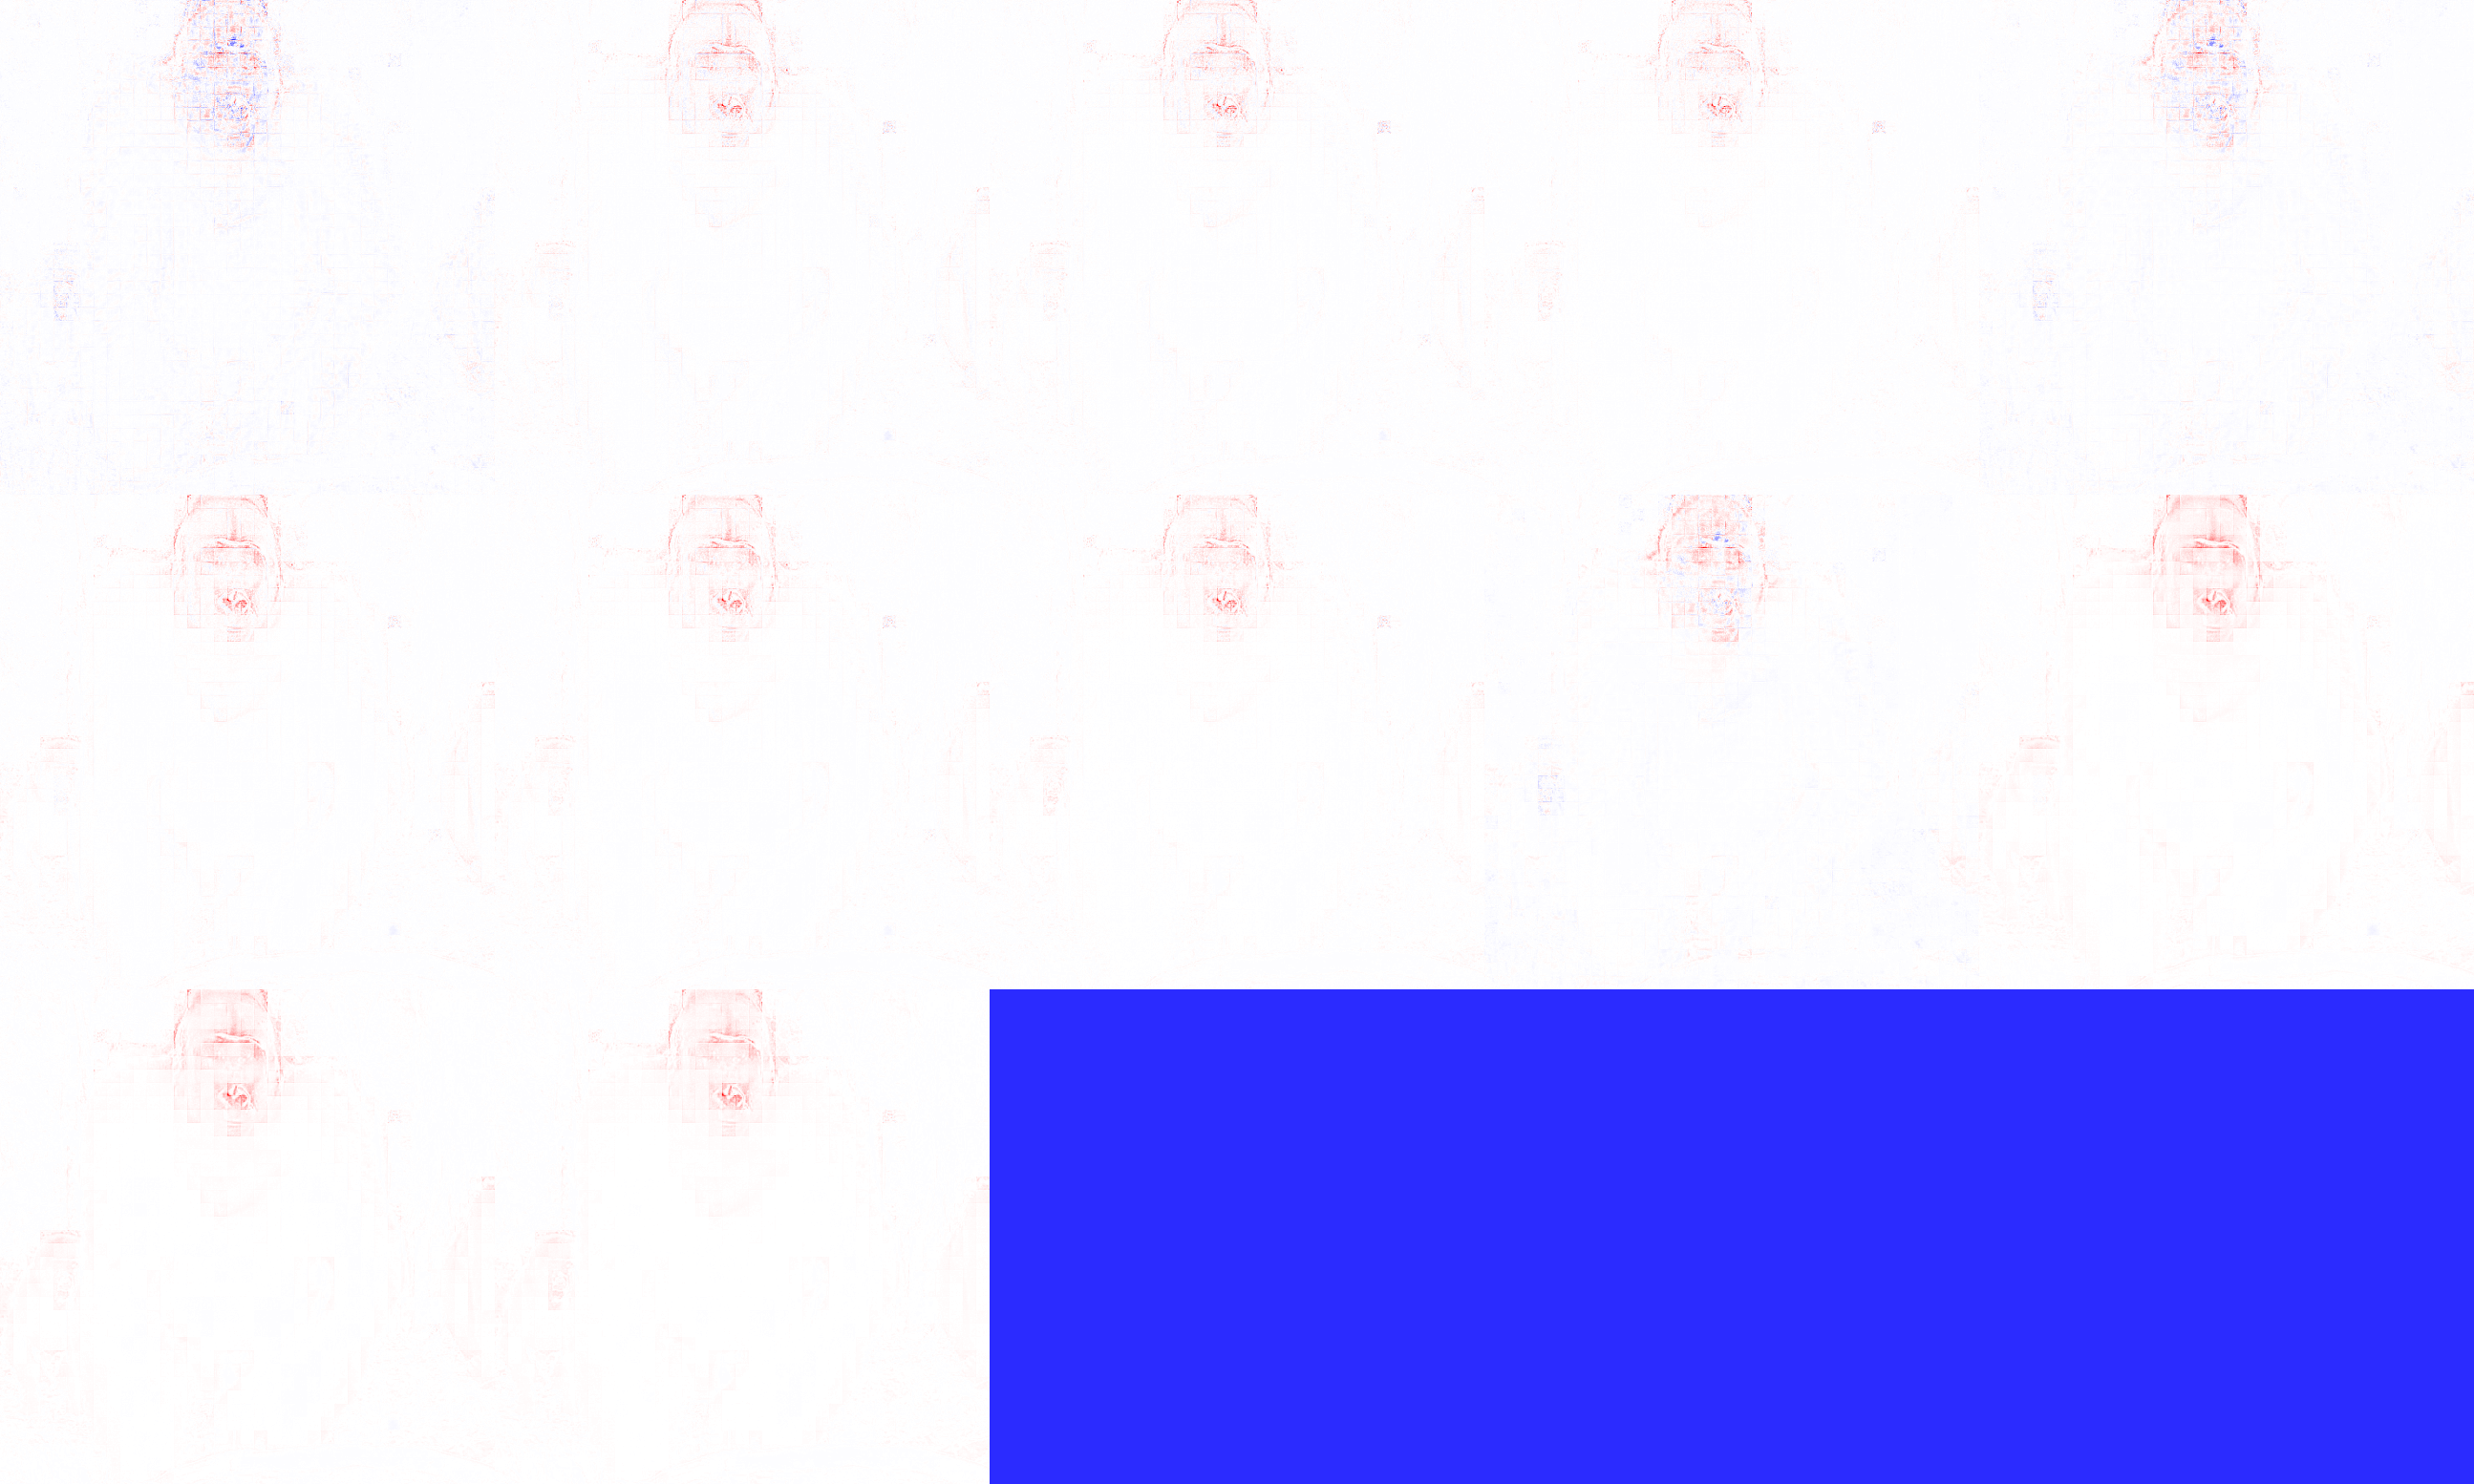

In [2]:
from zennit.image import imgify

imgify(heatmaps, vmin=-1, vmax=1, grid=(3, 5))

In [3]:
from segmentation import segment_images

_, images, resized_masks = segment_images()

INFO:root:Loaded checkpoint sucessfully


Fetching bounding box data for 19 detections from the database...


Querying DB: 100%|██████████| 1/1 [00:00<00:00, 15.76it/s]



Found 19 detections to process. Starting batch processing...


Overall Progress:   0%|          | 0/1 [00:00<?, ?it/s]INFO:root:Computing image embeddings for the provided images...
INFO:root:Image embeddings computed.
Overall Progress: 100%|██████████| 1/1 [01:10<00:00, 70.67s/it]

Batch 1/1 | Inference: 57.48s, Saving: 13.19s

--- Processing Complete ---
Total time: 79.44 seconds
Processed 19 detections.
Results saved to: /workspaces/bachelor_thesis_code/seg_test_out


INFO:matplotlib.font_manager:generated new fontManager


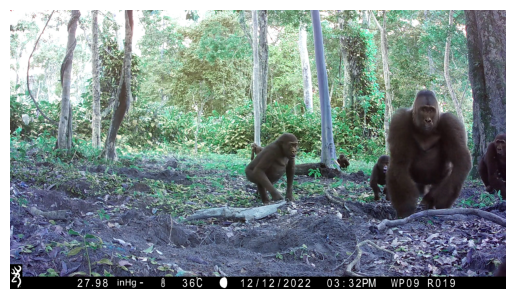

In [4]:
import matplotlib.pyplot as plt

plt.imshow(images[16])  # coloring slightly off?
plt.axis("off")
plt.show()

In [5]:
print(resized_masks[16].shape)
print(relevances[3].shape)

(518, 518)
torch.Size([1, 3, 518, 518])


In [6]:
from eval import attention_inside_mask

total, positive, negative = attention_inside_mask(resized_masks[16], relevances[3])
total, positive, negative

(0.826100766658783, 0.8255295753479004, 0.8301899433135986)